In [2]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, lr_scheduler
from torch.utils.data import Dataset, DataLoader, random_split
from torchmetrics.classification import MulticlassAccuracy
from torchvision import datasets, transforms
from torchvision.io import read_image, ImageReadMode
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
from collections import Counter

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

## Convolutional Neural Network

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
        self.conv5 = nn.Conv2d(32, 32, kernel_size=5, padding=1)
        
        self.fc1 = nn.Linear(128, 128)
        self.fc2 = nn.Linear(128, 4)

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(p=0.2)
    
    def forward(self, image):
        image = self.conv1(image)
        image = self.relu(image)
        image = self.pool(image)
        
        image = self.conv2(image)
        image = self.relu(image)
        image = self.pool(image)
        
        image = self.conv3(image)
        image = self.relu(image)
        image = self.pool(image)
        
        image = self.conv4(image)
        image = self.relu(image)
        image = self.pool(image)

        image = self.conv5(image)
        image = self.relu(image)
        image = self.pool(image)

        image = image.view(-1, 128)
        image = self.fc1(image)
        image = self.relu(image)
        image = self.dropout(image)
        image = self.fc2(image)
        return F.log_softmax(image, dim=1)

In [5]:
class CNNTrainer(pl.LightningModule):
    def __init__(self, num_classes=4, learning_rate=1e-4, weight_decay=1e-5):
        super(CNNTrainer, self).__init__()
        self.model = CNN()
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.num_classes = num_classes
        self.accuracy = MulticlassAccuracy(num_classes).to(device)

        self.val_labels = []
        self.val_preds = []
        self.test_labels = []
        self.test_preds = []
        

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = nn.CrossEntropyLoss()(y_hat, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        outputs = torch.argmax(outputs, dim=1)
        # acc = self.accuracy(outputs, labels)
        if self.current_epoch == self.trainer.max_epochs - 1:
            self.val_labels.extend(labels.cpu().numpy())
            self.val_preds.extend(outputs.cpu().numpy())
    
    def test_step(self, batch, batch_idx):
        inputs, labels = batch
        outputs = self(inputs)
        outputs = torch.argmax(outputs, dim=1)
        acc = self.accuracy(outputs, labels)
        self.log('test_acc', acc, on_epoch=True)
        self.test_labels.extend(labels.cpu().numpy())
        self.test_preds.extend(outputs.cpu().numpy())
        return {'test_acc': acc, 'test_outputs': outputs, 'test_labels': labels}

    def on_train_end(self):
        self.val_labels = np.array(self.val_labels)
        self.val_preds = np.array(self.val_preds)
        self.draw_cm(self.val_labels, self.val_preds, 'valConfMatrix')
    
    def on_test_end(self):
        self.test_labels = np.array(self.test_labels)
        self.test_preds = np.array(self.test_preds)
        self.draw_cm(self.test_labels, self.test_preds, 'testConfMatrix')
        
    def draw_cm(self, y, preds, file_name):
        cm = confusion_matrix(y, preds)
        ConfusionMatrixDisplay(cm).plot()
        plt.savefig(f'{file_name}.png', dpi=500)
    
        precision = precision_score(y, preds, average='macro')
        recall = recall_score(y, preds, average='macro')
    
        f1 = 2 * precision * recall / (precision + recall)
        f1_macro = f1_score(y, preds, average='macro')
        f1_weighted = f1_score(y, preds, average='weighted')
        print(f'Precision: {100 * precision:.3f} %')
        print(f'Recall: {100 * recall:.3f} %')
        print(f'F1 Score: {100 * f1:.3f} %')
        print(f'F1 Macro Score: {100 * f1_macro:.3f} %')
        print(f'F1 Weighted Score: {100 * f1_weighted:.3f} %')
        
    def configure_optimizers(self):
        optimizer = Adam(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss" 
            }
        }
        # return optimizer

In [6]:
train_data_path = '../../synt_one_channel_noise'
# train_data_path = '/mnt/jet1/zagorulia/val_one_channel'
val_data_path = '/mnt/jet1/zagorulia/val_one_channel'

data_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation((0, 360)),
    transforms.RandomAdjustSharpness(0.75, 1),
    transforms.ToTensor()
])
data = datasets.ImageFolder(train_data_path, transform=data_transform)

train_test_ratio = 0.8
train_size = int(train_test_ratio * len(data))
test_size = len(data) - train_size
train, test = random_split(data, [train_size, test_size])

batch_size = 128
trainloader = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=4)
testloader = DataLoader(test, batch_size=batch_size, num_workers=4)

## Training

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='./checkpoints/',
    filename='best-checkpoint',
    save_top_k=1,
    mode='min'
)
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=True,
    mode='min'
)

model = CNNTrainer()
trainer = pl.Trainer(
    max_epochs=50, log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping_callback]
)
trainer.fit(model, trainloader, testloader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/zagorulia/classifier/venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/zagorulia/classifier/venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /home/zagorulia/classifier/src/ml/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode 
---------------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 1.008


...

Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.835


Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved by 0.014 >= min_delta = 0.0. New best score: 0.821


Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.816


In [ ]:
best_model = CNNTrainer.load_from_checkpoint(trainer.checkpoint_callback.best_model_path)
torch.save(best_model.state_dict(), 'model.pt')

## Testing

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

Precision: 37.150 %
Recall: 36.794 %
F1 Score: 36.971 %
F1 Macro Score: 31.917 %
F1 Weighted Score: 40.428 %
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.15356291830539703
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_acc': 0.15356291830539703}]

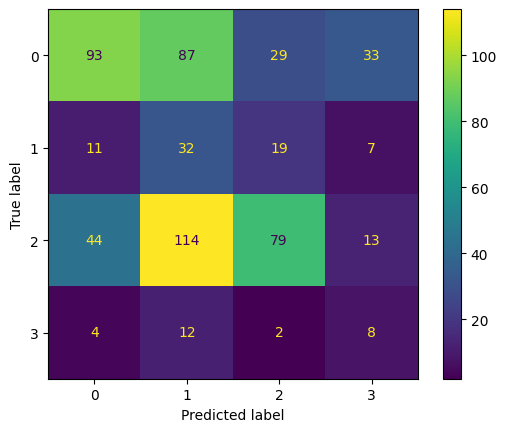

In [ ]:
val_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize(size=(128, 128)),
    transforms.ToTensor()
])
val = datasets.ImageFolder(val_data_path, transform=val_transform)
valloader = DataLoader(val, batch_size=batch_size, num_workers=4)

trainer.test(best_model, valloader)

## Morphological classification

In [ ]:
class AstrogeoDataset(Dataset):
    def __init__(self, dir, transform):
        self.transform = transform
        self.images = os.listdir(dir)
        self.dir = dir

    def __getitem__(self, index):
        image = read_image(
            f'{self.dir}/{self.images[index]}',
            mode=ImageReadMode.RGB
        )
        file_name = self.images[index]
        image = self.transform(image)
        return (file_name, image)

    def __len__(self):
        return len(self.images)

In [ ]:
transform = transforms.Compose([
    transforms.ToPILImage(), transforms.Grayscale(),
    transforms.Resize((128, 128)), transforms.ToTensor()
])
morph = AstrogeoDataset(data_path, transform=transform)
morphloader = DataLoader(morph, batch_size=batch_size, shuffle=True, num_workers=4)

model.to(device)
model.eval()
morph_preds = {}
with torch.no_grad():
    for file_names, images in tqdm(morphloader):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        morph_preds.update(dict(zip(file_names, predicted.cpu().tolist())))
        
with open('predicts.json', 'w') as f:
    json.dump(morph_preds, f)

s1 = pd.Series(morph_preds.keys())
s2 = pd.Series(morph_preds.values())
df = pd.concat([s1, s2], axis=1)
df = df.rename(columns={0: 'file_name', 1: 'predicted_class'})
df.to_csv('classification.csv')

NameError: name 'data_path' is not defined

{0: 1003, 1: 112342, 2: 18564, 3: 62}


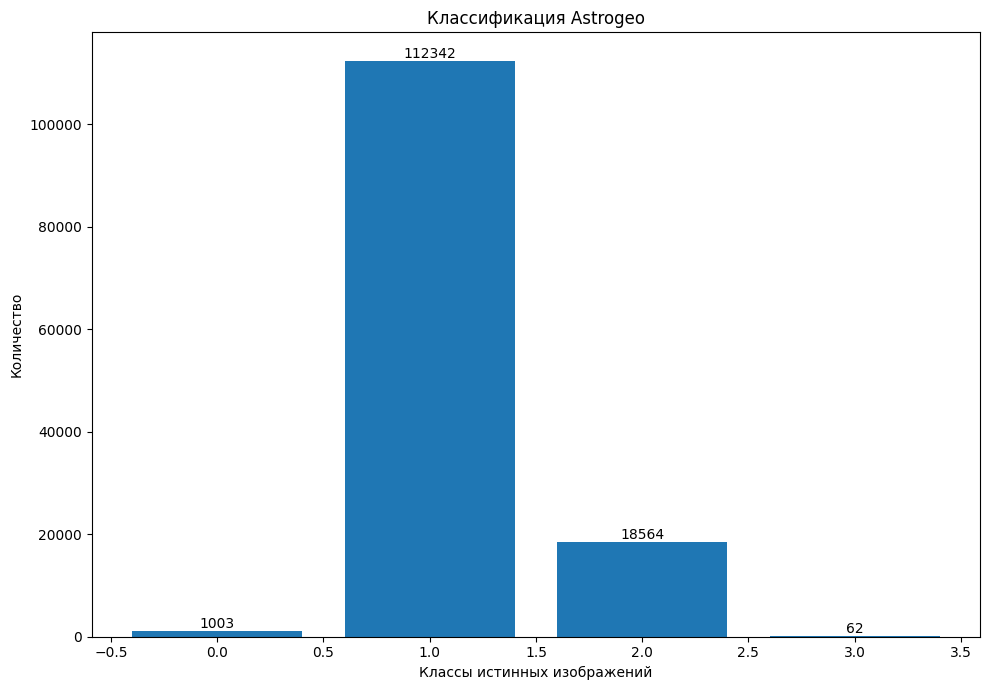

In [ ]:
labels = [
    'Одиночный источник', 'Двойной источник',
    'Источник с джетом', 'Источник с двойным джетом'
]
res = dict(Counter(morph_preds.values()))
res = {k: v for k, v in sorted(res.items())}
print(res)
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
bar = ax.bar(res.keys(), res.values())
ax.bar_label(bar, labels=res.values())
ax.set_xlabel('Классы истинных изображений')
ax.set_ylabel('Количество')
ax.set_title('Классификация Astrogeo')
fig.tight_layout()
plt.savefig('histogram.png', dpi=500)

In [ ]:
# plt.rcParams.update({'font.size': 16})
# epochs = np.arange(1, num_epochs + 1)
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# axes[0].plot(epochs, LossTrain, label='train', color='blue')
# axes[0].plot(epochs, LossTest, label='test', color='orange')
# # axes[0].set_title('Loss(epoch)')
# axes[0].set_xlabel('Epoch')
# axes[0].set_ylabel('Loss')
# axes[0].grid()
# axes[0].legend()

# axes[1].plot(epochs, AccTrain, label='train', color='blue')
# axes[1].plot(epochs, AccTest, label='test', color='orange')
# # axes[1].set_title('Accuracy(epoch)')
# axes[1].set_ylabel('Accuracy')
# axes[1].set_xlabel('Epoch')
# axes[1].grid()
# axes[1].legend()
# plt.tight_layout()
# plt.savefig('train.png', dpi=500)